# Baseline model: predicting temporal AIT activity from static DINOv3 features

## Main idea

This notebook predicts the complete temporal AIT population response to a static image using a frozen DINOv3 representation and a small trainable temporal decoder. The model does not receive a video or any other temporal input. Instead, it learns a sequence of temporal queries that extracts a different mixture of DINO layers at each neural-response time point.

The central hypothesis is therefore:

> Can a learned time-dependent mixture of static DINO layer representations explain the temporal evolution of AIT population responses?

The complete pipeline is:

```text
Static image
    |
    +-- Frozen DINOv3 ViT-L, or cached DINOv3 activations
    |
    v
Four layer representations [B, 4, 1024]
    |
    +-- key projection   -> [B, 4, 128]
    +-- value projection -> [B, 4, 128]
    |
Learned temporal queries [30, 128]
    |
    v
Attention over DINO layers at each time point [B, 30, 4]
    |
    v
Time-indexed latent representation [B, 30, 128]
    |
    v
Temporal MLP and neural prediction MLP
    |
    v
Predicted AIT activity [B, 30 time bins, 25 neurons]
```

## Executed configuration

The saved execution uses monkey `three0`, session `250313`, area `AIT`, and stimulus set `talia_20each_tizi`. Neural activity is taken from `natraster` between 0 and 300 ms and resampled from 1000 Hz to 100 Hz, producing 30 ten-millisecond bins. The resulting data contain 776 stimuli and 25 AIT channels.

The visual backbone is DINOv3 ViT-L/16 at an input resolution of 224 x 224 pixels. Mean-pooled representations are taken from layers 3, 13, 16, and 20. Each selected layer contributes a 1024-dimensional vector. The current run uses cached activations with shape `[776, 4, 1024]`; raw-image input is also supported.

Training uses a batch size of 64, a 20% validation fraction, 400 epochs, AdamW with learning rate `1e-3` and weight decay `1e-4`, and dropout `0.5`. The temporal embedding and value dimensions are both 128, while the hidden dimension of the two decoder MLPs is 32.

## 1. Neural-data loading and alignment

The neural loaders return activity with shape `[neurons, time, samples]`. Two source formats are supported:

- `natraster`, used in the saved run, contains unique-image averaged responses. It loads the requested temporal window, converts the data to `float32`, selects the requested brain-area channels, resamples the signal, and aligns its stimulus dimension to the `ImageFolder` ordering. The executed result has shape `[25, 30, 776]`.
- `raster` contains repeated single trials. It loads neural data in chunks, reads the filename associated with each trial, and maps every occurrence to the corresponding source image. Repeated presentations remain separate neural samples.

Stimulus alignment is an essential part of the pipeline. `neural_image_indices` maps every neural sample to the correct row of the image dataset or cached activation array. The notebook checks that the number of mappings agrees with the neural sample dimension and that every mapped index is valid.

## 2. Visual inputs and frozen DINO features

Images are indexed through `torchvision.datasets.ImageFolder`. `ProcessorTransform` applies the preprocessing recipe saved with the Hugging Face checkpoint, and the notebook verifies that the processor returns the configured 224 x 224 spatial resolution. Class labels created by `ImageFolder` are not used.

There are two input modes:

- With `training_input_mode="activations"`, the loader returns precomputed features with shape `[layers, embedding] = [4, 1024]`. This is the efficient default because the backbone is frozen.
- With `training_input_mode="images"`, the loader returns a processed image with shape `[3, 224, 224]`. DINO is then run online under `torch.no_grad()`, and forward hooks collect the selected layer outputs.

In both modes, DINO is used only as a fixed feature extractor. All its parameters have `requires_grad=False`, and the model overrides `train()` so that the backbone remains in evaluation mode while the decoder is trained.

## 3. Dataset and DataLoaders

`NeuralInputDataset` joins each visual input to its neural target. It transposes neural activity from `[neurons, time, samples]` to `[samples, time, neurons]`. A sample therefore contains either cached features `[4, 1024]` or an image `[3, 224, 224]`, together with a target `[30, 25]`.

The class performs early checks for invalid modes, missing cached activations, incorrect tensor dimensions, mismatches between neural trials and image mappings, and indices outside the source image dataset.

The train/validation split is made over unique image identities rather than directly over trials. This is important in `raster` mode: every repeated presentation of one image is kept in the same partition, preventing image leakage. The executed split contains 621 training images and 155 validation images. Training batches are shuffled; validation batches are not.

## 4. Model architecture

### Frozen encoder

The encoder is a 24-block DINOv3 ViT-L with embedding dimension 1024. Only four intermediate layer representations are retained. The trainable network operates on these representations rather than modifying the backbone.

### Key and value projections

Each layer vector is projected into key and value spaces. In the current configuration, both have dimension 128:

```text
layer features X: [B, 4, 1024]
keys K:           [B, 4, 128]
values V:         [B, 4, 128]
```

Layer normalization and dropout are applied after both projections.

### Learned temporal queries and layer attention

The network learns one query for every coarse neural time point. With 30 target bins and a temporal compression ratio of one, there are 30 queries of dimension 128. Queries are shared across images, but their attention weights are stimulus-dependent because the keys are computed from the current image.

For each time point, scaled dot-product attention is computed over the four DINO layers:

$$A_{btl} = \operatorname{softmax}_l\left(\frac{Q_t K_{bl}^{T}}{\sqrt{d_k}}\right).$$

The softmax is over network layers, not over time. A weighted sum of the projected values then produces one latent vector for every time point:

$$Z_{bt} = \sum_l A_{btl}V_{bl}.$$

The attention matrix `[B, 30, 4]` can consequently be interpreted as an image- and time-dependent preference over DINO depth.

### Pointwise temporal features and neural prediction

The temporal feature MLP is `Linear(128, 32) -> GELU -> Dropout -> Linear(32, 128)`. It acts only on the final feature dimension and therefore processes every time bin independently. The compression ratio is required to equal one, so every temporal query corresponds to exactly one neural time bin.

A shared pointwise feature MLP, `Linear(128, 32) -> GELU -> Dropout`, processes each time-indexed latent without mixing time points. It is followed by 30 separate `Linear(32, 25)` readout heads, one for each target bin. Head `t` sees only latent `t`, and its weights receive loss gradients only from neural target `t`. The final output has shape `[B, 30, 25]`. Excluding the frozen DINO backbone, the current model has approximately 304,000 trainable parameters.

## 5. Meaning of temporal modelling in this baseline

The model is temporal in its output parameterization, but it is neither recurrent nor autoregressive. All 30 time points are predicted simultaneously. There is no RNN, GRU, LSTM, temporal self-attention, or state passed from one time point to the next.

Temporal structure is generated mainly by the sequence of learned queries: different time points can select different mixtures of DINO layers. The feature transformations are applied pointwise, and the final neural readout weights are specific to each time bin. The compression ratio is required to be one, so time points do not communicate directly. This model therefore tests time-dependent layer selection and time-specific neural mappings rather than temporal state evolution.

## 6. Loss function

The training objective first computes a separate mean-squared error for every time bin:

$$\mathcal{L}_t = \frac{1}{BN}\sum_{b,n}(\hat{y}_{btn}-y_{btn})^2, \qquad \mathcal{L}=\frac{1}{T}\sum_t\mathcal{L}_t.$$

Prediction bin `t` is compared only with neural target bin `t`; the loss contains no shifted, adjacent-bin, or all-pairs temporal terms. The scalar used for backpropagation is the equal average of the 30 time-bin losses. There is no per-neuron normalization, time-dependent weighting, Poisson likelihood, correlation loss, noise-ceiling correction, attention regularization, or temporal-smoothness penalty. Responses with larger variance can therefore have a larger effect on the optimization.

## 7. Optimization and training loop

AdamW receives only parameters for which `requires_grad=True`: temporal embeddings, key/value projections, normalization parameters, decoder MLPs, and an optional query projection. DINO parameters are excluded.

During one training epoch, the notebook:

1. Sets the decoder to training mode while keeping DINO in evaluation mode.
2. Moves inputs and neural targets to the selected device.
3. Runs the forward pass and computes the aligned loss separately for every time bin.
4. Backpropagates the loss.
5. Applies one AdamW update.
6. Clears gradients with `zero_grad(set_to_none=True)`.
7. Accumulates the batch loss weighted by its number of samples.

The gradient reset occurs after each optimizer step, with an initial reset before training. This is valid, although resetting immediately before the forward pass is the more common convention. There is no learning-rate scheduler, gradient clipping, mixed-precision training, early stopping, or model checkpointing.

## 8. Validation and diagnostics

The randomly initialized decoder is evaluated before the first update. After every training epoch, the complete validation set is evaluated with the model in evaluation mode and gradient tracking disabled. A fixed validation example is plotted every ten epochs; prediction and target are averaged across neurons to leave one temporal trajectory. This plot is intuitive but can hide channel-specific errors.

After training, attention weights are collected for all validation images and averaged across stimuli. The resulting layer-by-time heatmap is the main interpretability output: it shows whether early and late neural predictions rely on different DINO depths.

## 9. Ridge-regression reference

The notebook also fits a simpler linear reference. The four DINO vectors are concatenated into 4096 input features, while the complete neural response is flattened into 750 outputs (`30 time bins * 25 neurons`). Ridge regression is fitted on the same image-grouped training split and evaluated on the same validation split.

The imported implementation uses `RidgeCV` over ten candidate alphas from `1e-6` to `1e3`. The later notebook description calls this a fixed-alpha ridge model, but the implementation actually performs alpha selection on the training data.

## 10. Results in the saved execution

The saved outputs below were produced by the preceding shared-readout version and must be regenerated after introducing the time-bin-specific heads. In that preceding run, the randomly initialized model started at validation MSE `0.065310`; ridge obtained `0.045250`; and the neural model reached approximately `0.044928` around epoch 33. These numbers are retained only as a historical reference and are not results for the time-local architecture.

The time-local architecture must be rerun before it can be compared with ridge. The notebook still does not retain the best validation checkpoint, so the final model need not be the best model encountered during training.

## 11. Strengths and current limitations

Important strengths are explicit alignment checks, image-grouped data splitting, efficient cached-feature training, careful freezing of DINO, interpretable layer attention, and comparison against a strong linear reference. The same model can use cached activations during training and raw images during inference.

The main limitations are:

- There is one train/validation split and no independent test set or cross-validation.
- NumPy controls the split seed, but PyTorch initialization, dropout, and DataLoader shuffling are not fully seeded.
- There is no early stopping or best-model checkpoint.
- Aggregate MSE is not complemented by per-neuron correlation, R-squared, explained variance, or noise-ceiling-normalized scores.
- There is no temporal smoothness or biologically motivated latency constraint.
- With compression ratio one, there is no explicit interaction between time points.
- The model can reveal changing layer preferences, but cannot establish whether recurrent state evolution is required to explain AIT dynamics.

This makes the notebook a useful, interpretable baseline for later comparisons with recurrent, state-space, or temporally interacting models.

In [1]:
import os
import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]

# Put this repository first so another project's package cannot shadow it.
project_src_path = str((PROJECT_ROOT / "python_scripts" / "src").resolve())
useful_stuff_path = str(Path(paths["useful_stuff_path"]).resolve())
for source_path in (useful_stuff_path, project_src_path):
    while source_path in sys.path:
        sys.path.remove(source_path)
    # end while source path is already registered
    sys.path.insert(0, source_path)
# end for source path

# Reimport the development loader even if an older copy is kernel-cached.
sys.modules.pop("project_specific_utils.dataloader", None)
sys.modules.pop("project_specific_utils", None)
import project_specific_utils.dataloader as neural_dataloader
expected_dataloader_path = (
    Path(project_src_path) / "project_specific_utils" / "dataloader.py"
).resolve()
loaded_dataloader_path = Path(neural_dataloader.__file__).resolve()
if loaded_dataloader_path != expected_dataloader_path:
    raise ImportError(
        f"Expected neural loader {expected_dataloader_path}, loaded "
        f"{loaded_dataloader_path}."
    )
# end if a different project's loader was imported

# from II_analyses.static_encoding import (
#     compute_static_prediction_II,
#     fit_static_projection,
# )
from project_specific_utils.dataloader import (
    load_img_natraster,
    load_img_raster,
    make_neural_input_loader,
    map_image_order_from_ann_to_monkey,
    map_trial_image_order_to_ann,
)
from IT_recap.hf_feature_extraction import (
    ProcessorTransform,
    is_valid_image_file,
    load_hf_layer_features,
)
from IT_recap.neural_prediction_training import (
    collect_concatenated_layer_regression_data,
    neural_activity_timebin_mse_loss,
    plot_mean_channel_reconstruction,
    test_step,
    training_step,
)
from model_classes.temporal_models import BaselineModel
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.image_processing.computational_models import imgANN


In [2]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    # Paul natraster example: source="natraster", monkey="paul",
    # date="230204", folder="fewer_occlusion".
    neural_data_source: str = "natraster"  # "raster" or "natraster"
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    raster_file: str = "rasters_three0_250313to21.mat" # None #"paul_nat" #
    raster_key: str = "rasters"
    raster_image_names_file: str = "allimages_three0_250313to21.mat"
    raster_image_names_key: str = "allimages"
    original_fs: int = 1000
    new_fs: int = 100
    time_start_ms: float = 0.0
    time_end_ms: float = 300.0
    raster_chunk_size: int = 512
    # pca_comp = 100
    # Static model-feature parameters.
    model_name: str = "dino_v3_l"
    model_source: str = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    img_size: int = 224
    use_fast_processor: bool = True
    pkg = "hf"
    layer_names: list[str] = field(default_factory=lambda: [
        "layer.3.mlp.down_proj",
        "layer.13.mlp.down_proj",
        "layer.16.mlp.down_proj",
        "layer.20.mlp.down_proj",
    ])
    pooling: str = "mean"
    trust_remote_code = True
    attn_implementation = "sdpa"
    # Use "images" if cached DINO features do not exist for folder_name.
    training_input_mode: str = "activations"  #"images" # "images" or "activations"

    batch_size = 64
    validation_fraction: float = 0.2
    random_seed: int = 0
    epochs: int = 400
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    temporal_embedding_dim: int = 128
    value_dim: int = 128
    temporal_compression_ratio: int = 1
    mlp_hidden_dim: int = 32
    dropout: float = 0.5
    reconstruction_plot_interval: int = 10
    reconstruction_sample_index: int = 10
    
# EOC


cfg = Cfg()
cfg

Cfg(neural_data_source='natraster', monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', raster_file='rasters_three0_250313to21.mat', raster_key='rasters', raster_image_names_file='allimages_three0_250313to21.mat', raster_image_names_key='allimages', original_fs=1000, new_fs=100, time_start_ms=0.0, time_end_ms=300.0, raster_chunk_size=512, model_name='dino_v3_l', model_source='facebook/dinov3-vitl16-pretrain-lvd1689m', img_size=224, use_fast_processor=True, layer_names=['layer.3.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.16.mlp.down_proj', 'layer.20.mlp.down_proj'], pooling='mean', training_input_mode='activations', validation_fraction=0.2, random_seed=0, epochs=400, learning_rate=0.001, weight_decay=0.0001, temporal_embedding_dim=128, value_dim=128, temporal_compression_ratio=1, mlp_hidden_dim=32, dropout=0.5, reconstruction_plot_interval=10, reconstruction_sample_index=10)

## Load and align the static spaces

The neural data are shaped `(neurons, timepoints, samples)`. With `neural_data_source="raster"`, samples are repeated single trials and their explicit presentation names determine the image mapping. With `neural_data_source="natraster"`, samples are unique-image averages and the ordering follows `run_static_dRSA.py`: `load_img_natraster` plus `map_image_order_from_ann_to_monkey`. Cached DINO features remain in ImageFolder source order.

In [3]:
# Load the preprocessing recipe saved with the Hugging Face checkpoint.
image_processor = AutoImageProcessor.from_pretrained(
    cfg.model_source,
    use_fast=cfg.use_fast_processor,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    transform=ProcessorTransform(image_processor),
    is_valid_file=is_valid_image_file,
    allow_empty=True,
)

# Fail early if the checkpoint processor and configured model size disagree.
sample_image, _ = dataset[0]
sample_shape = tuple(sample_image.shape[-2:])
if sample_shape != (cfg.img_size, cfg.img_size):
    raise ValueError(
        f"Processor returned {sample_shape}, expected "
        f"{(cfg.img_size, cfg.img_size)}."
    )
# end if processor output size differs from model input size

# Align neural samples to ImageFolder following the appropriate source format.
if cfg.neural_data_source == "raster":
    raster, neural_image_names = load_img_raster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        raster_file=cfg.raster_file,
        image_names_file=cfg.raster_image_names_file,
        raster_key=cfg.raster_key,
        image_names_key=cfg.raster_image_names_key,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
        chunk_size=cfg.raster_chunk_size,
    )
    neural_image_indices = map_trial_image_order_to_ann(
        neural_image_names,
        dataset,
    )
elif cfg.neural_data_source == "natraster":
    # Match run_static_dRSA.py: natraster rows follow sorted unique names.
    raster = load_img_natraster(
        paths=paths,
        monkey_name=cfg.monkey_name,
        date=cfg.date,
        original_fs=cfg.original_fs,
        new_fs=cfg.new_fs,
        time_start_ms=cfg.time_start_ms,
        time_end_ms=cfg.time_end_ms,
        brain_area=cfg.brain_area,
    )
    neural_image_indices = np.asarray(
        map_image_order_from_ann_to_monkey(
            paths,
            cfg.monkey_name,
            cfg.date,
            dataset,
        ),
        dtype=int,
    )
else:
    raise ValueError(
        "neural_data_source must be either 'raster' or 'natraster'."
    )
# end if repeated raster or averaged natraster is requested

raster_array = raster.get_array()

if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, trials), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3

if len(neural_image_indices) != raster_array.shape[2]:
    raise ValueError(
        f"Found {len(neural_image_indices)} aligned images but "
        f"{raster_array.shape[2]} neural samples."
    )
# end if neural data and image ordering differ

# Cached DINO outputs are needed only when bypassing the frozen backbone.
precomputed_layer_features = None
if cfg.training_input_mode == "activations":
    precomputed_layer_features = load_hf_layer_features(
        output_dir=Path(paths["data_path"]) / "models",
        dataset_name=cfg.folder_name,
        model_name=cfg.model_name,
        img_size=cfg.img_size,
        layer_names=cfg.layer_names,
        pooling=cfg.pooling,
    )
    if precomputed_layer_features.shape[0] != len(dataset):
        raise ValueError(
            "Cached features and ImageFolder have different image counts: "
            f"{precomputed_layer_features.shape[0]} and {len(dataset)}."
        )
    # end if cached features and ImageFolder are misaligned
elif cfg.training_input_mode != "images":
    raise ValueError(
        "training_input_mode must be either 'images' or 'activations'."
    )
# end if cached features are requested

print(f"{cfg.neural_data_source} neural data: {raster_array.shape}")
print(f"Aligned unique stimuli: {len(np.unique(neural_image_indices))}")
if precomputed_layer_features is not None:
    print(f"Cached DINO features: {precomputed_layer_features.shape}")
else:
    print("Training input: images (DINO runs online)")
# end if cached features were loaded


natraster neural data: (25, 30, 776)
Aligned unique stimuli: 776
Cached DINO features: (776, 4, 1024)


In [4]:
# NeuralInputDataset is implemented in project_specific_utils.dataloader.


In [5]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.img_size,
    pooling=cfg.pooling,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.model_source,
    trust_remote_code=cfg.trust_remote_code,
)

18:01:22 - device being used: mps


In [6]:
# Change cfg.training_input_mode to switch the training input source.
loader = make_neural_input_loader(
    input_mode=cfg.training_input_mode,
    image_dataset=dataset,
    activations=precomputed_layer_features,
    neural_activity=raster_array,
    image_indices=neural_image_indices,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=torch.device(ann.get_device()).type == "cuda",
)


In [7]:
# BaselineModel is implemented in model_classes.temporal_models.


## Time-bin-specific neural-activity prediction loss

The loss is computed separately at each time bin. Prediction bin $t$ is compared only with neural target bin $t$:

$$\mathcal{L}_t = \frac{1}{BN} \sum_{b,n} (\hat{y}_{btn} - y_{btn})^2.$$

The scalar training objective is the equal average of those independent time-bin losses:

$$\mathcal{L} = \frac{1}{T} \sum_t \mathcal{L}_t.$$

There are no comparisons between different time bins and no temporal shifting or temporal averaging before the error is computed.

In [8]:
# neural_activity_timebin_mse_loss is implemented in IT_recap.neural_prediction_training.


# Training and online validation
## training (repeat for the whole training set -> 1 epoch)
1. Pass minibatch
2. compute loss
3. backpropagate
4. do the optimizer step
5. zero the gradient
6. accumulate the sample-weighted training loss

## testing (repeat for the whole validation set at every epoch)
1. switch the network to evaluation mode
2. compute the loss
3. accumulate the sample-weighted validation loss


In [9]:
# Training, validation, plotting, and ridge-data helpers are implemented in IT_recap.neural_prediction_training.


In [10]:
m = BaselineModel(
    ann,
    layers=cfg.layer_names,
    temporal_embedding_dim=cfg.temporal_embedding_dim,
    value_dim=cfg.value_dim,
    n_timepoints=raster_array.shape[1],
    temporal_compression_ratio=cfg.temporal_compression_ratio,
    n_neurons=raster_array.shape[0],
    mlp_hidden_dim=cfg.mlp_hidden_dim,
    dropout=cfg.dropout,
).to(ann.get_device())
m

BaselineModel(
  (encoder_backbone): DINOv3ViTModel(
    (embeddings): DINOv3ViTEmbeddings(
      (patch_embeddings): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (rope_embeddings): DINOv3ViTRopePositionEmbedding()
    (layer): ModuleList(
      (0-23): 24 x DINOv3ViTLayer(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (attention): DINOv3ViTAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (layer_scale1): DINOv3ViTLayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): DINOv3ViTMLP(
          (up_proj): Linear(in_features=1024, out_features=4096, bias=True)
    

split: 621 images / 621 trials for training; 155 images / 155 trials for validation
concatenated-layer ridge | validation 0.045250
epoch 000/400 | validation 0.064655


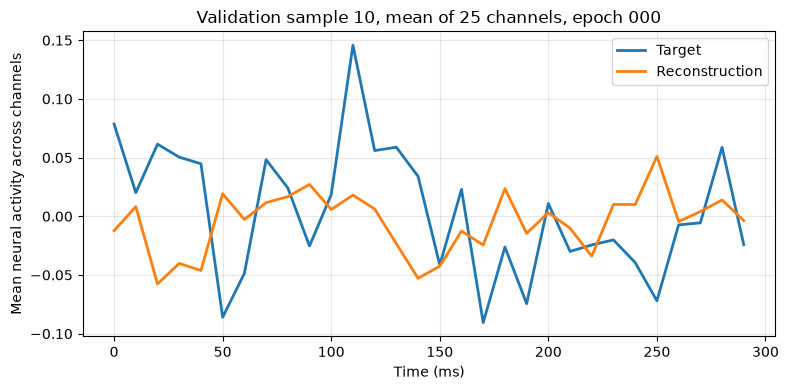

epoch 001/400 | train 0.064263 | validation 0.060448
epoch 002/400 | train 0.060413 | validation 0.056117
epoch 003/400 | train 0.056626 | validation 0.052239
epoch 004/400 | train 0.053612 | validation 0.049846
epoch 005/400 | train 0.051539 | validation 0.048436
epoch 006/400 | train 0.050279 | validation 0.047640
epoch 007/400 | train 0.049372 | validation 0.047168
epoch 008/400 | train 0.048711 | validation 0.046874
epoch 009/400 | train 0.048228 | validation 0.046470
epoch 010/400 | train 0.047826 | validation 0.046262


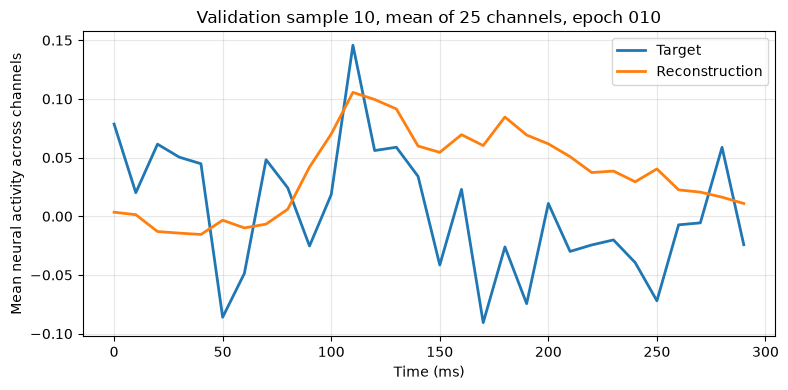

epoch 011/400 | train 0.047503 | validation 0.045995
epoch 012/400 | train 0.047308 | validation 0.045982
epoch 013/400 | train 0.047077 | validation 0.045954
epoch 014/400 | train 0.046870 | validation 0.045826
epoch 015/400 | train 0.046716 | validation 0.045651
epoch 016/400 | train 0.046517 | validation 0.045767
epoch 017/400 | train 0.046447 | validation 0.045495
epoch 018/400 | train 0.046295 | validation 0.045513
epoch 019/400 | train 0.046191 | validation 0.045322
epoch 020/400 | train 0.046047 | validation 0.045291


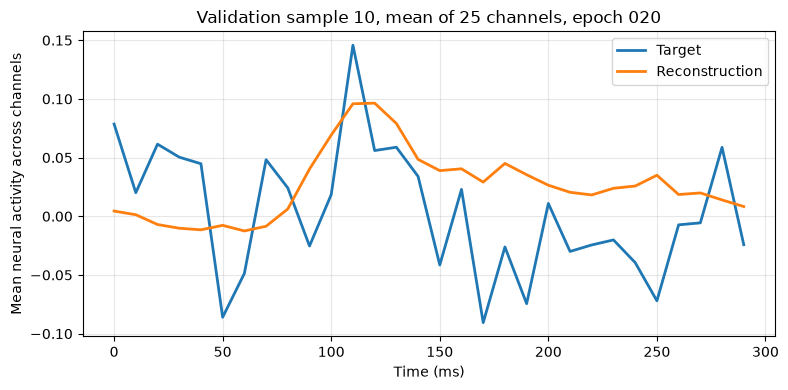

epoch 021/400 | train 0.045952 | validation 0.045351
epoch 022/400 | train 0.045840 | validation 0.045086
epoch 023/400 | train 0.045846 | validation 0.045318
epoch 024/400 | train 0.045669 | validation 0.045085
epoch 025/400 | train 0.045583 | validation 0.045113
epoch 026/400 | train 0.045533 | validation 0.045004
epoch 027/400 | train 0.045397 | validation 0.045042
epoch 028/400 | train 0.045299 | validation 0.045148
epoch 029/400 | train 0.045261 | validation 0.044930
epoch 030/400 | train 0.045193 | validation 0.044984


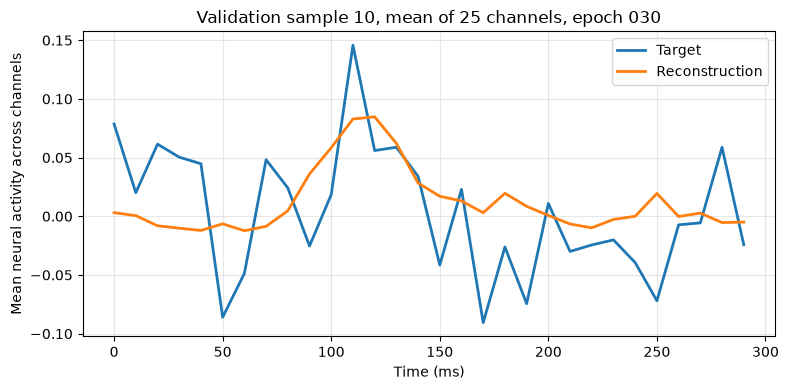

epoch 031/400 | train 0.045195 | validation 0.044928
epoch 032/400 | train 0.045158 | validation 0.045024
epoch 033/400 | train 0.045083 | validation 0.044992
epoch 034/400 | train 0.044970 | validation 0.044882
epoch 035/400 | train 0.044981 | validation 0.044891
epoch 036/400 | train 0.044894 | validation 0.044922
epoch 037/400 | train 0.044859 | validation 0.044972
epoch 038/400 | train 0.044829 | validation 0.044907
epoch 039/400 | train 0.044798 | validation 0.044905
epoch 040/400 | train 0.044729 | validation 0.044887


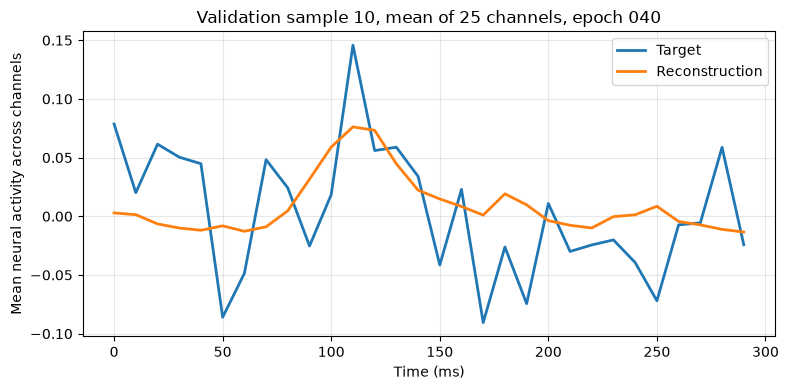

epoch 041/400 | train 0.044735 | validation 0.044994
epoch 042/400 | train 0.044685 | validation 0.044854
epoch 043/400 | train 0.044649 | validation 0.044964
epoch 044/400 | train 0.044581 | validation 0.044883
epoch 045/400 | train 0.044600 | validation 0.044920
epoch 046/400 | train 0.044513 | validation 0.044955
epoch 047/400 | train 0.044550 | validation 0.044898
epoch 048/400 | train 0.044462 | validation 0.044858
epoch 049/400 | train 0.044504 | validation 0.044880
epoch 050/400 | train 0.044441 | validation 0.044983


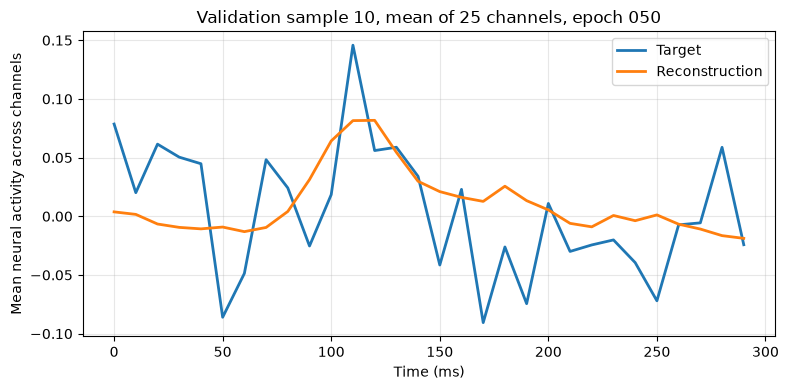

epoch 051/400 | train 0.044467 | validation 0.044891
epoch 052/400 | train 0.044399 | validation 0.044882
epoch 053/400 | train 0.044434 | validation 0.044896
epoch 054/400 | train 0.044427 | validation 0.045133
epoch 055/400 | train 0.044449 | validation 0.045066
epoch 056/400 | train 0.044421 | validation 0.045028
epoch 057/400 | train 0.044298 | validation 0.044883
epoch 058/400 | train 0.044253 | validation 0.044935
epoch 059/400 | train 0.044263 | validation 0.044991
epoch 060/400 | train 0.044254 | validation 0.044920


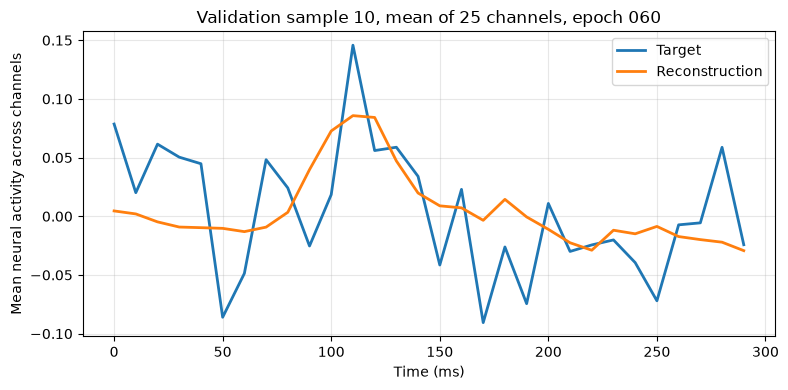

epoch 061/400 | train 0.044238 | validation 0.044924
epoch 062/400 | train 0.044153 | validation 0.044941
epoch 063/400 | train 0.044149 | validation 0.044967
epoch 064/400 | train 0.044167 | validation 0.044962
epoch 065/400 | train 0.044152 | validation 0.045024
epoch 066/400 | train 0.044157 | validation 0.044961
epoch 067/400 | train 0.044124 | validation 0.045054
epoch 068/400 | train 0.044099 | validation 0.044990
epoch 069/400 | train 0.044137 | validation 0.044947
epoch 070/400 | train 0.044053 | validation 0.044948


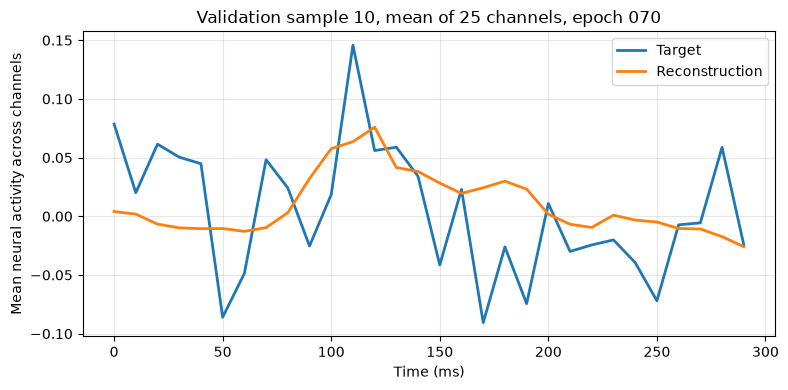

epoch 071/400 | train 0.044008 | validation 0.045032
epoch 072/400 | train 0.044049 | validation 0.045086
epoch 073/400 | train 0.043982 | validation 0.044988
epoch 074/400 | train 0.043974 | validation 0.044988
epoch 075/400 | train 0.043966 | validation 0.045030
epoch 076/400 | train 0.043955 | validation 0.045020
epoch 077/400 | train 0.043909 | validation 0.045063
epoch 078/400 | train 0.043937 | validation 0.044980
epoch 079/400 | train 0.043894 | validation 0.045030
epoch 080/400 | train 0.043856 | validation 0.045048


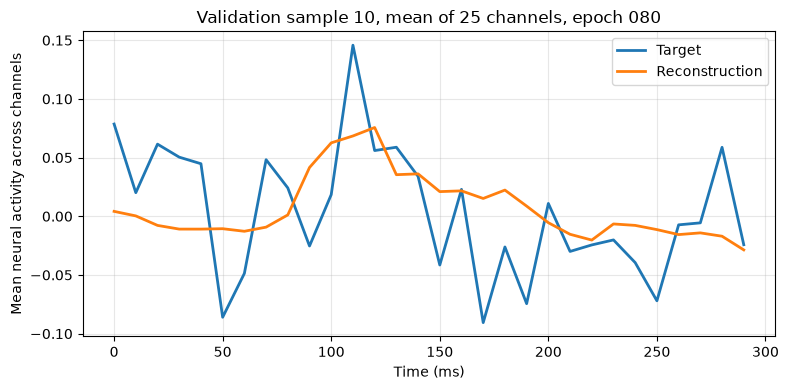

epoch 081/400 | train 0.043868 | validation 0.045115
epoch 082/400 | train 0.043831 | validation 0.045138
epoch 083/400 | train 0.043891 | validation 0.045083
epoch 084/400 | train 0.043825 | validation 0.045040
epoch 085/400 | train 0.043820 | validation 0.045099
epoch 086/400 | train 0.043860 | validation 0.045024
epoch 087/400 | train 0.043772 | validation 0.045113
epoch 088/400 | train 0.043809 | validation 0.045072
epoch 089/400 | train 0.043789 | validation 0.045088
epoch 090/400 | train 0.043746 | validation 0.045142


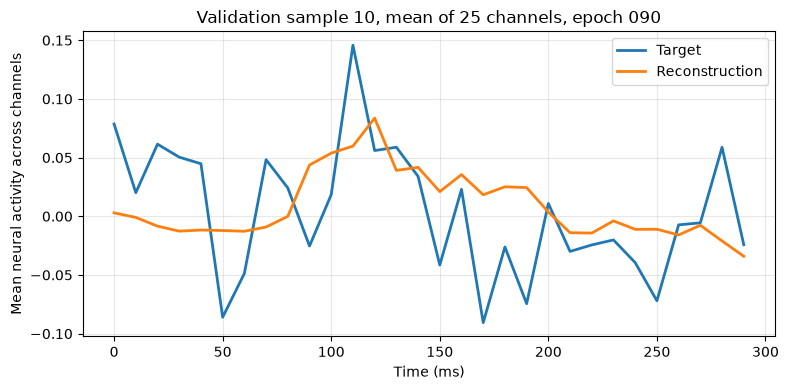

epoch 091/400 | train 0.043716 | validation 0.045081
epoch 092/400 | train 0.043717 | validation 0.045132
epoch 093/400 | train 0.043717 | validation 0.045072
epoch 094/400 | train 0.043673 | validation 0.045120
epoch 095/400 | train 0.043666 | validation 0.045132
epoch 096/400 | train 0.043702 | validation 0.045128
epoch 097/400 | train 0.043703 | validation 0.045111
epoch 098/400 | train 0.043666 | validation 0.045188
epoch 099/400 | train 0.043651 | validation 0.045223
epoch 100/400 | train 0.043645 | validation 0.045164


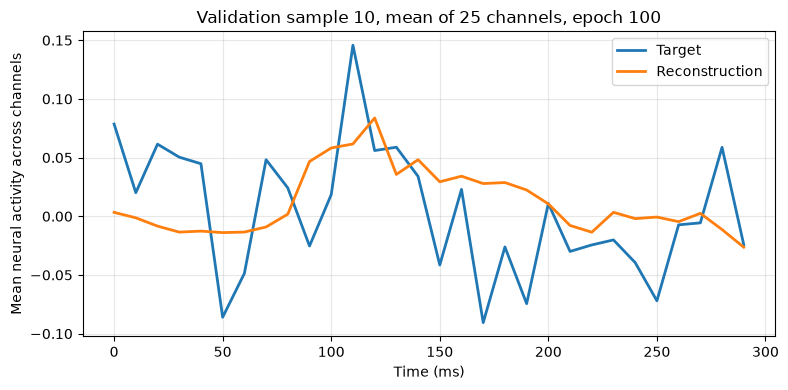

epoch 101/400 | train 0.043572 | validation 0.045172
epoch 102/400 | train 0.043635 | validation 0.045257
epoch 103/400 | train 0.043626 | validation 0.045147
epoch 104/400 | train 0.043583 | validation 0.045162
epoch 105/400 | train 0.043546 | validation 0.045214
epoch 106/400 | train 0.043595 | validation 0.045218
epoch 107/400 | train 0.043570 | validation 0.045236
epoch 108/400 | train 0.043544 | validation 0.045258
epoch 109/400 | train 0.043555 | validation 0.045192
epoch 110/400 | train 0.043485 | validation 0.045217


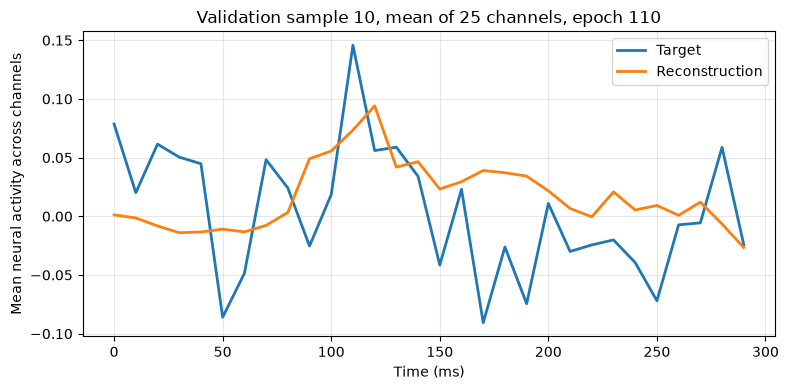

epoch 111/400 | train 0.043493 | validation 0.045222
epoch 112/400 | train 0.043491 | validation 0.045220
epoch 113/400 | train 0.043507 | validation 0.045249
epoch 114/400 | train 0.043524 | validation 0.045369
epoch 115/400 | train 0.043509 | validation 0.045275
epoch 116/400 | train 0.043471 | validation 0.045310
epoch 117/400 | train 0.043428 | validation 0.045269
epoch 118/400 | train 0.043403 | validation 0.045237
epoch 119/400 | train 0.043425 | validation 0.045200
epoch 120/400 | train 0.043404 | validation 0.045297


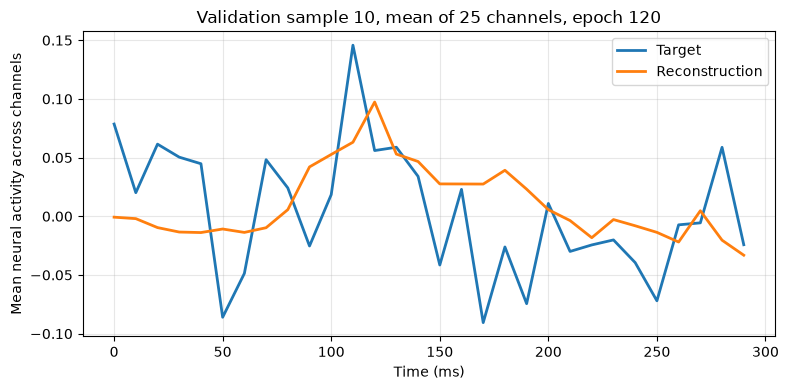

epoch 121/400 | train 0.043382 | validation 0.045316
epoch 122/400 | train 0.043368 | validation 0.045256
epoch 123/400 | train 0.043358 | validation 0.045346
epoch 124/400 | train 0.043359 | validation 0.045314
epoch 125/400 | train 0.043402 | validation 0.045308
epoch 126/400 | train 0.043352 | validation 0.045290
epoch 127/400 | train 0.043297 | validation 0.045375
epoch 128/400 | train 0.043333 | validation 0.045405
epoch 129/400 | train 0.043310 | validation 0.045316
epoch 130/400 | train 0.043311 | validation 0.045362


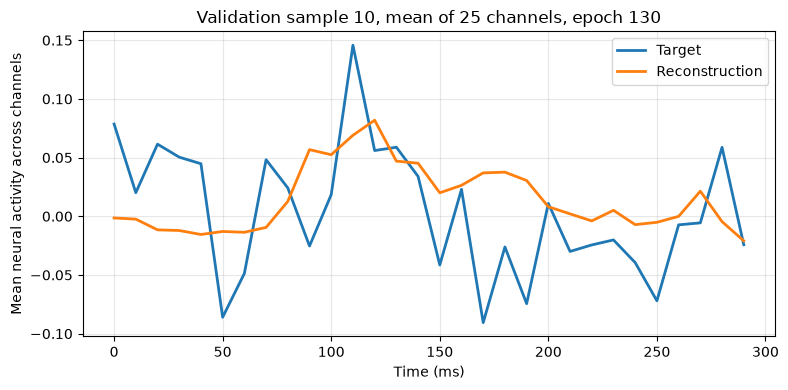

epoch 131/400 | train 0.043312 | validation 0.045265
epoch 132/400 | train 0.043296 | validation 0.045370
epoch 133/400 | train 0.043307 | validation 0.045259
epoch 134/400 | train 0.043248 | validation 0.045307
epoch 135/400 | train 0.043244 | validation 0.045295
epoch 136/400 | train 0.043264 | validation 0.045375
epoch 137/400 | train 0.043252 | validation 0.045454
epoch 138/400 | train 0.043223 | validation 0.045413
epoch 139/400 | train 0.043258 | validation 0.045446
epoch 140/400 | train 0.043181 | validation 0.045403


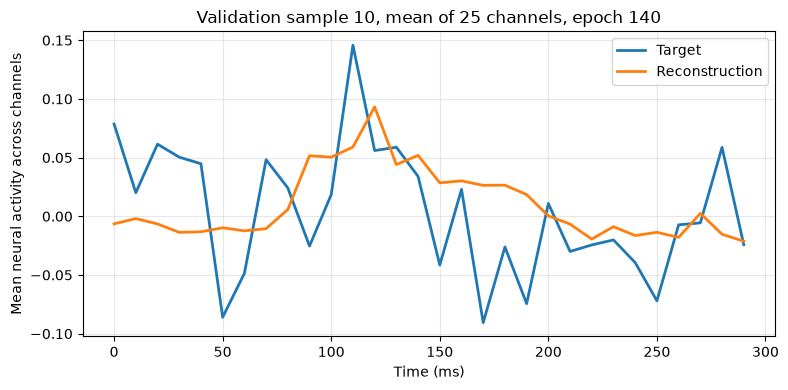

epoch 141/400 | train 0.043205 | validation 0.045361
epoch 142/400 | train 0.043155 | validation 0.045558
epoch 143/400 | train 0.043224 | validation 0.045441
epoch 144/400 | train 0.043171 | validation 0.045517
epoch 145/400 | train 0.043174 | validation 0.045401
epoch 146/400 | train 0.043142 | validation 0.045344
epoch 147/400 | train 0.043126 | validation 0.045348
epoch 148/400 | train 0.043171 | validation 0.045493
epoch 149/400 | train 0.043167 | validation 0.045392
epoch 150/400 | train 0.043159 | validation 0.045410


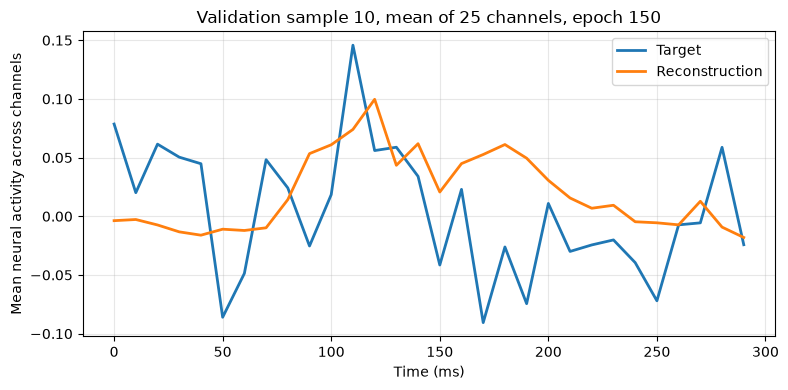

epoch 151/400 | train 0.043150 | validation 0.045506
epoch 152/400 | train 0.043076 | validation 0.045536
epoch 153/400 | train 0.043108 | validation 0.045456
epoch 154/400 | train 0.043125 | validation 0.045381
epoch 155/400 | train 0.043068 | validation 0.045462
epoch 156/400 | train 0.043110 | validation 0.045577
epoch 157/400 | train 0.043073 | validation 0.045572
epoch 158/400 | train 0.043054 | validation 0.045499
epoch 159/400 | train 0.043056 | validation 0.045390
epoch 160/400 | train 0.043080 | validation 0.045430


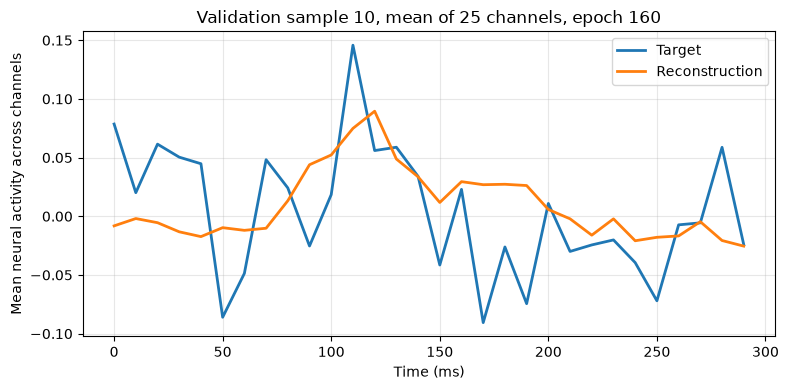

epoch 161/400 | train 0.043040 | validation 0.045394
epoch 162/400 | train 0.043010 | validation 0.045506
epoch 163/400 | train 0.043041 | validation 0.045505
epoch 164/400 | train 0.043003 | validation 0.045456
epoch 165/400 | train 0.042986 | validation 0.045466
epoch 166/400 | train 0.042959 | validation 0.045506
epoch 167/400 | train 0.042980 | validation 0.045543
epoch 168/400 | train 0.042974 | validation 0.045632
epoch 169/400 | train 0.043004 | validation 0.045693
epoch 170/400 | train 0.042973 | validation 0.045509


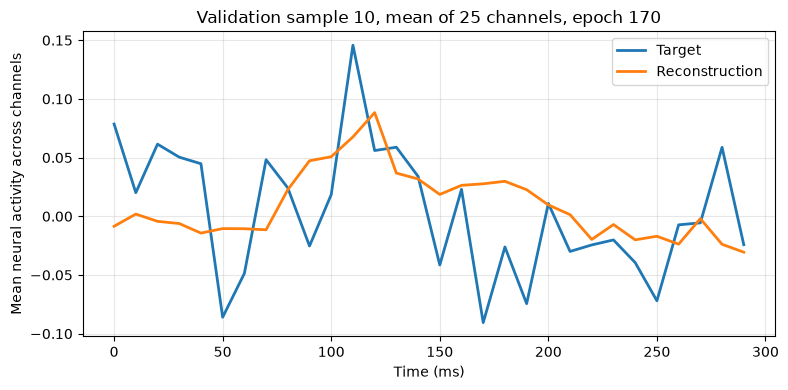

epoch 171/400 | train 0.042964 | validation 0.045500
epoch 172/400 | train 0.042949 | validation 0.045524
epoch 173/400 | train 0.042954 | validation 0.045541
epoch 174/400 | train 0.042950 | validation 0.045466
epoch 175/400 | train 0.042929 | validation 0.045622
epoch 176/400 | train 0.042967 | validation 0.045614
epoch 177/400 | train 0.042941 | validation 0.045620
epoch 178/400 | train 0.042885 | validation 0.045598
epoch 179/400 | train 0.042884 | validation 0.045571
epoch 180/400 | train 0.042897 | validation 0.045591


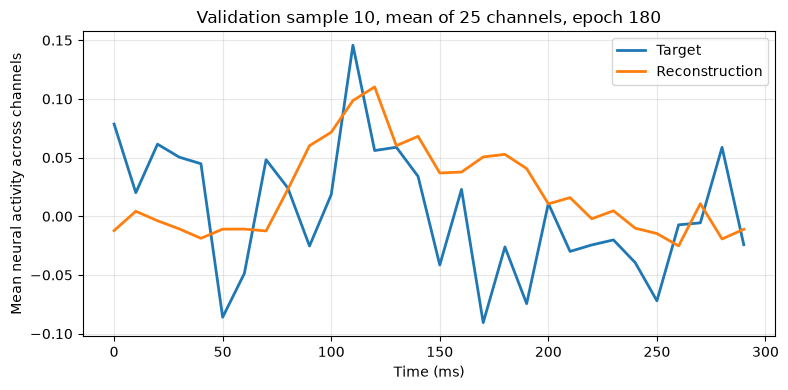

epoch 181/400 | train 0.042907 | validation 0.045620
epoch 182/400 | train 0.042880 | validation 0.045684
epoch 183/400 | train 0.042919 | validation 0.045578
epoch 184/400 | train 0.042869 | validation 0.045590
epoch 185/400 | train 0.042854 | validation 0.045555
epoch 186/400 | train 0.042858 | validation 0.045565
epoch 187/400 | train 0.042856 | validation 0.045573
epoch 188/400 | train 0.042851 | validation 0.045565
epoch 189/400 | train 0.042808 | validation 0.045646
epoch 190/400 | train 0.042798 | validation 0.045684


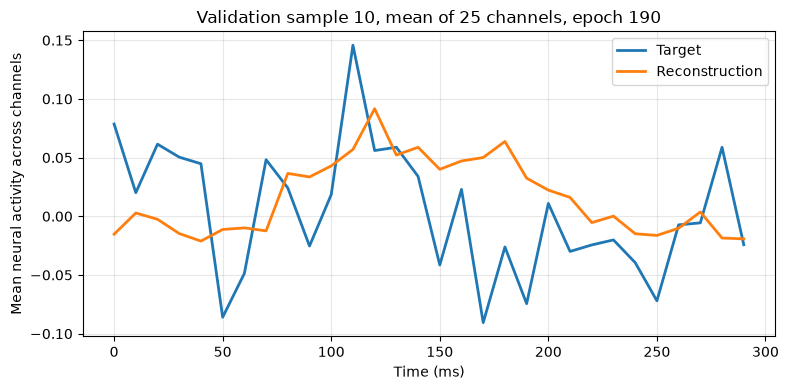

epoch 191/400 | train 0.042854 | validation 0.045554
epoch 192/400 | train 0.042781 | validation 0.045716
epoch 193/400 | train 0.042789 | validation 0.045609
epoch 194/400 | train 0.042808 | validation 0.045820
epoch 195/400 | train 0.042800 | validation 0.045625
epoch 196/400 | train 0.042766 | validation 0.045629
epoch 197/400 | train 0.042757 | validation 0.045630
epoch 198/400 | train 0.042759 | validation 0.045661
epoch 199/400 | train 0.042768 | validation 0.045777
epoch 200/400 | train 0.042751 | validation 0.045746


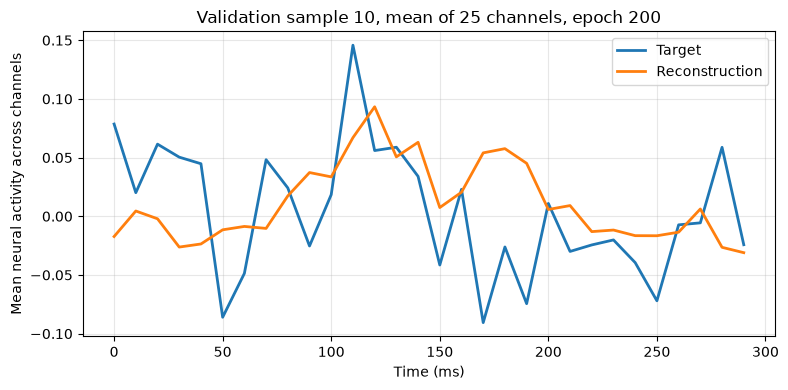

epoch 201/400 | train 0.042753 | validation 0.045772
epoch 202/400 | train 0.042728 | validation 0.045727
epoch 203/400 | train 0.042721 | validation 0.045787
epoch 204/400 | train 0.042702 | validation 0.045813
epoch 205/400 | train 0.042771 | validation 0.045710
epoch 206/400 | train 0.042743 | validation 0.045583
epoch 207/400 | train 0.042740 | validation 0.045711
epoch 208/400 | train 0.042764 | validation 0.045665
epoch 209/400 | train 0.042756 | validation 0.045689
epoch 210/400 | train 0.042752 | validation 0.045594


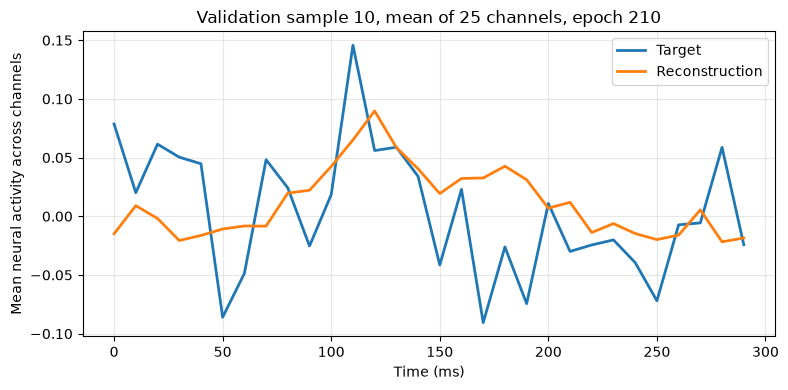

epoch 211/400 | train 0.042779 | validation 0.045693
epoch 212/400 | train 0.042754 | validation 0.045681
epoch 213/400 | train 0.042740 | validation 0.045611
epoch 214/400 | train 0.042703 | validation 0.045689
epoch 215/400 | train 0.042706 | validation 0.045711
epoch 216/400 | train 0.042664 | validation 0.045731
epoch 217/400 | train 0.042639 | validation 0.045756
epoch 218/400 | train 0.042650 | validation 0.045668
epoch 219/400 | train 0.042637 | validation 0.045708
epoch 220/400 | train 0.042652 | validation 0.045711


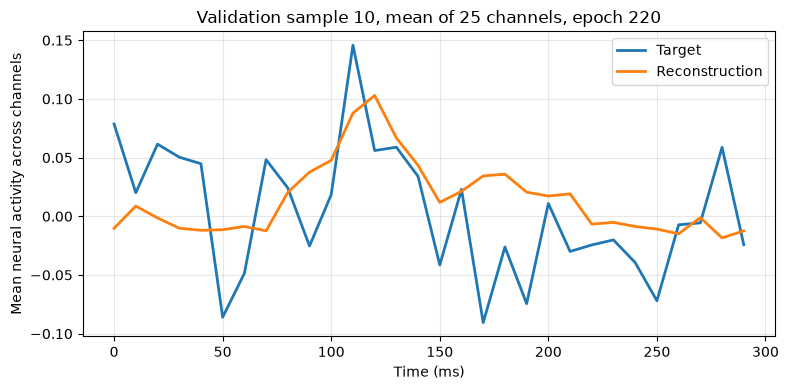

epoch 221/400 | train 0.042710 | validation 0.045700
epoch 222/400 | train 0.042655 | validation 0.045730
epoch 223/400 | train 0.042623 | validation 0.045735
epoch 224/400 | train 0.042615 | validation 0.045773
epoch 225/400 | train 0.042623 | validation 0.045726
epoch 226/400 | train 0.042617 | validation 0.045791
epoch 227/400 | train 0.042592 | validation 0.045841
epoch 228/400 | train 0.042623 | validation 0.045817
epoch 229/400 | train 0.042618 | validation 0.045836
epoch 230/400 | train 0.042591 | validation 0.045797


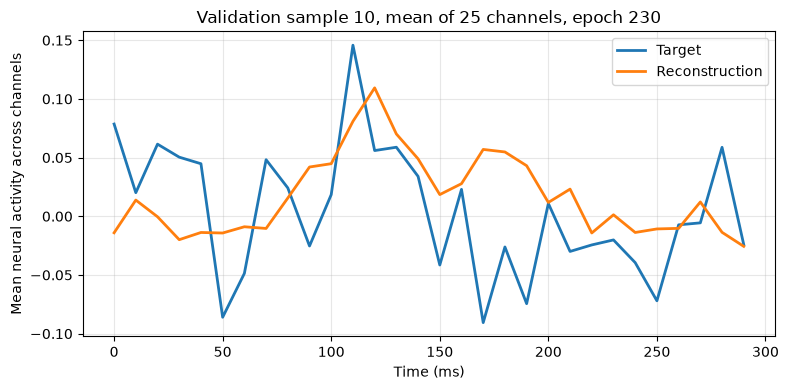

epoch 231/400 | train 0.042592 | validation 0.045808
epoch 232/400 | train 0.042579 | validation 0.045779
epoch 233/400 | train 0.042605 | validation 0.045696
epoch 234/400 | train 0.042640 | validation 0.045771
epoch 235/400 | train 0.042582 | validation 0.045741
epoch 236/400 | train 0.042589 | validation 0.045743
epoch 237/400 | train 0.042573 | validation 0.045773
epoch 238/400 | train 0.042575 | validation 0.045684
epoch 239/400 | train 0.042595 | validation 0.045806
epoch 240/400 | train 0.042504 | validation 0.045833


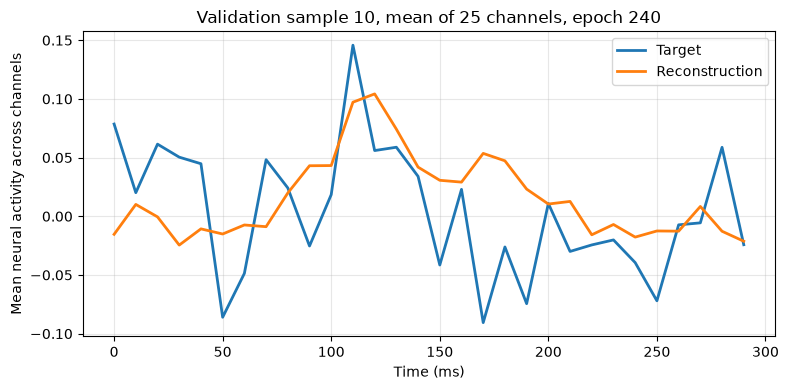

epoch 241/400 | train 0.042519 | validation 0.045850
epoch 242/400 | train 0.042482 | validation 0.045795
epoch 243/400 | train 0.042527 | validation 0.045867
epoch 244/400 | train 0.042518 | validation 0.045746
epoch 245/400 | train 0.042487 | validation 0.045794
epoch 246/400 | train 0.042508 | validation 0.045781
epoch 247/400 | train 0.042533 | validation 0.045655
epoch 248/400 | train 0.042484 | validation 0.045710
epoch 249/400 | train 0.042480 | validation 0.045646
epoch 250/400 | train 0.042466 | validation 0.045782


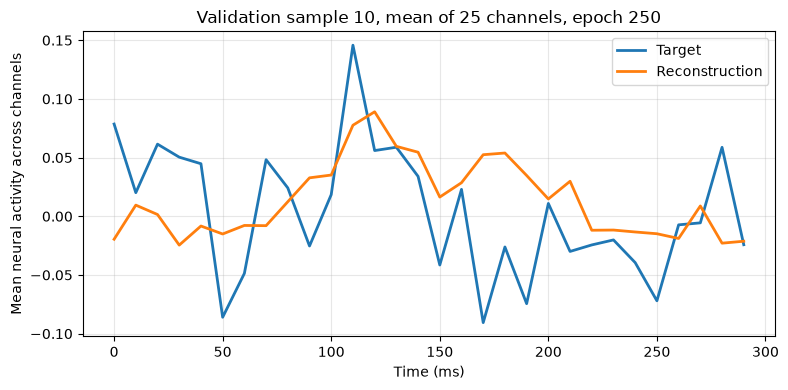

epoch 251/400 | train 0.042476 | validation 0.045813
epoch 252/400 | train 0.042451 | validation 0.045905
epoch 253/400 | train 0.042511 | validation 0.045784
epoch 254/400 | train 0.042482 | validation 0.045818
epoch 255/400 | train 0.042434 | validation 0.045806
epoch 256/400 | train 0.042458 | validation 0.045696
epoch 257/400 | train 0.042490 | validation 0.045694
epoch 258/400 | train 0.042454 | validation 0.045686
epoch 259/400 | train 0.042421 | validation 0.045686
epoch 260/400 | train 0.042422 | validation 0.045816


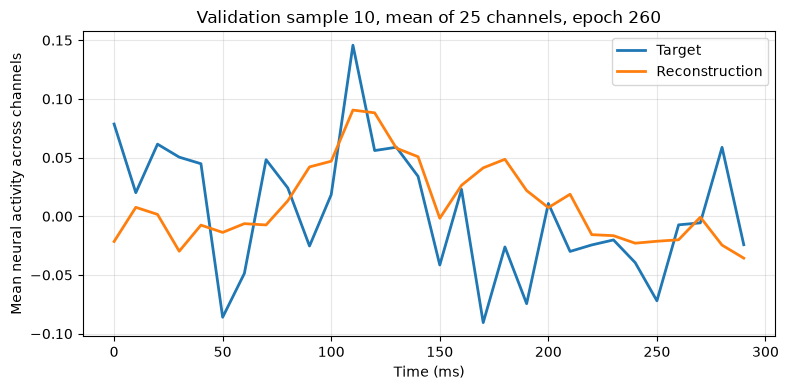

epoch 261/400 | train 0.042390 | validation 0.045774
epoch 262/400 | train 0.042374 | validation 0.045819
epoch 263/400 | train 0.042428 | validation 0.045798
epoch 264/400 | train 0.042393 | validation 0.045779
epoch 265/400 | train 0.042411 | validation 0.045846
epoch 266/400 | train 0.042360 | validation 0.045960
epoch 267/400 | train 0.042372 | validation 0.045749
epoch 268/400 | train 0.042387 | validation 0.045710
epoch 269/400 | train 0.042407 | validation 0.045719
epoch 270/400 | train 0.042391 | validation 0.045789


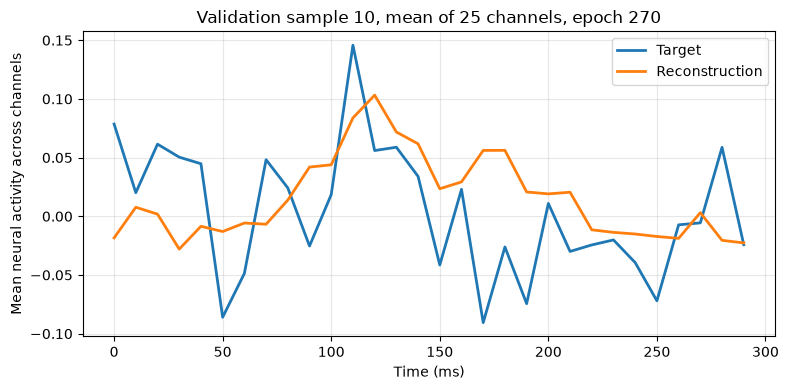

epoch 271/400 | train 0.042321 | validation 0.045719
epoch 272/400 | train 0.042356 | validation 0.045724
epoch 273/400 | train 0.042336 | validation 0.045878
epoch 274/400 | train 0.042422 | validation 0.045921
epoch 275/400 | train 0.042375 | validation 0.045740
epoch 276/400 | train 0.042367 | validation 0.045769
epoch 277/400 | train 0.042318 | validation 0.045767
epoch 278/400 | train 0.042339 | validation 0.045741
epoch 279/400 | train 0.042335 | validation 0.045722
epoch 280/400 | train 0.042363 | validation 0.045865


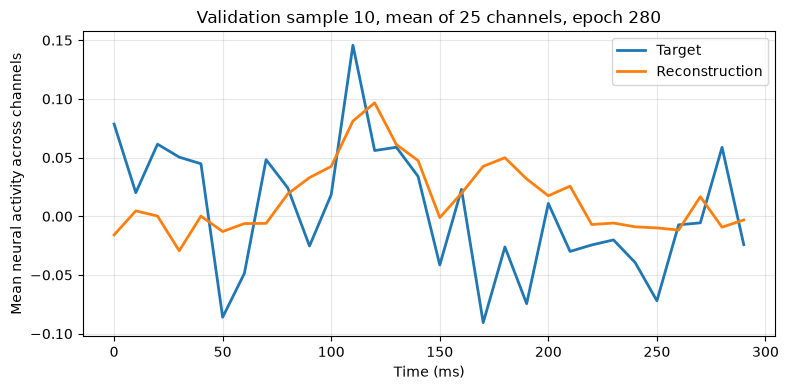

epoch 281/400 | train 0.042311 | validation 0.045748
epoch 282/400 | train 0.042355 | validation 0.045839
epoch 283/400 | train 0.042342 | validation 0.045837
epoch 284/400 | train 0.042313 | validation 0.045892
epoch 285/400 | train 0.042324 | validation 0.046063
epoch 286/400 | train 0.042324 | validation 0.046033
epoch 287/400 | train 0.042274 | validation 0.045980
epoch 288/400 | train 0.042263 | validation 0.045977
epoch 289/400 | train 0.042246 | validation 0.045863
epoch 290/400 | train 0.042321 | validation 0.045873


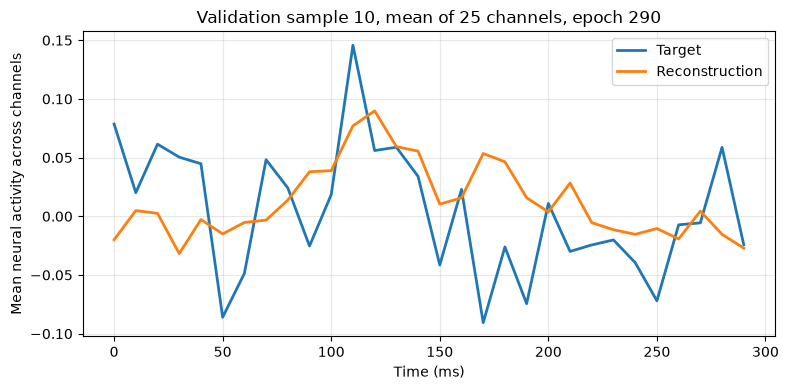

epoch 291/400 | train 0.042239 | validation 0.045880
epoch 292/400 | train 0.042253 | validation 0.045696
epoch 293/400 | train 0.042301 | validation 0.045796
epoch 294/400 | train 0.042281 | validation 0.045845
epoch 295/400 | train 0.042278 | validation 0.045875
epoch 296/400 | train 0.042252 | validation 0.045705
epoch 297/400 | train 0.042250 | validation 0.045755
epoch 298/400 | train 0.042183 | validation 0.045828
epoch 299/400 | train 0.042208 | validation 0.045739
epoch 300/400 | train 0.042194 | validation 0.045755


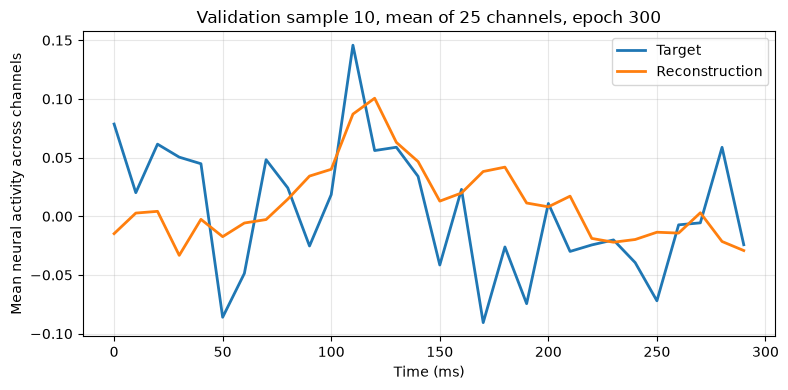

epoch 301/400 | train 0.042251 | validation 0.045827
epoch 302/400 | train 0.042219 | validation 0.045762
epoch 303/400 | train 0.042203 | validation 0.045677
epoch 304/400 | train 0.042245 | validation 0.045812
epoch 305/400 | train 0.042217 | validation 0.045736
epoch 306/400 | train 0.042199 | validation 0.045725
epoch 307/400 | train 0.042229 | validation 0.045851
epoch 308/400 | train 0.042178 | validation 0.045890
epoch 309/400 | train 0.042215 | validation 0.045889
epoch 310/400 | train 0.042642 | validation 0.046037


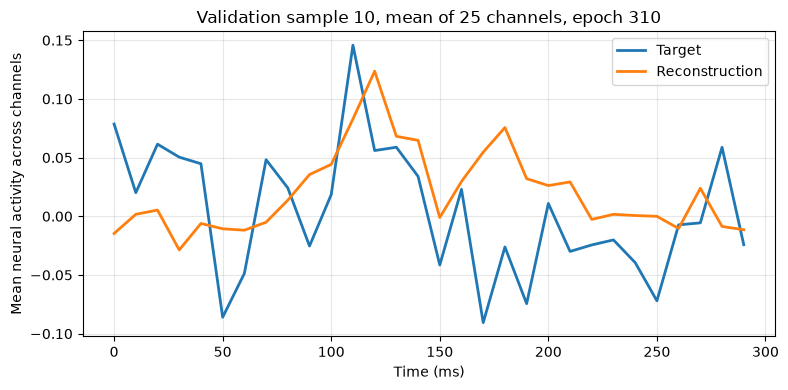

epoch 311/400 | train 0.042838 | validation 0.045719
epoch 312/400 | train 0.042695 | validation 0.045593
epoch 313/400 | train 0.042597 | validation 0.045595
epoch 314/400 | train 0.042549 | validation 0.045666
epoch 315/400 | train 0.042523 | validation 0.045505
epoch 316/400 | train 0.042524 | validation 0.045631
epoch 317/400 | train 0.042460 | validation 0.045743
epoch 318/400 | train 0.042374 | validation 0.045697
epoch 319/400 | train 0.042295 | validation 0.045707
epoch 320/400 | train 0.042245 | validation 0.045883


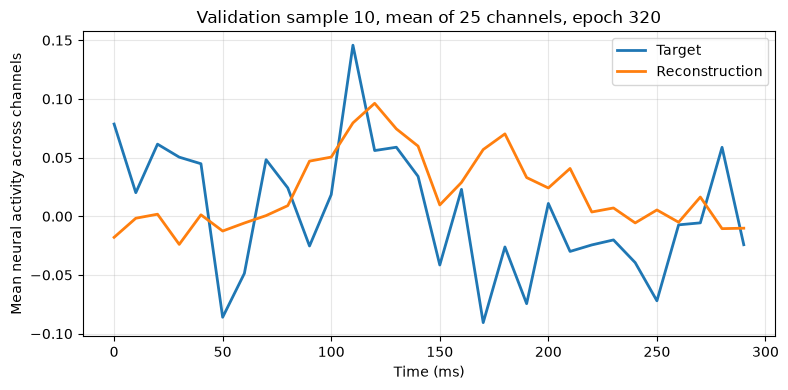

epoch 321/400 | train 0.042238 | validation 0.045721
epoch 322/400 | train 0.042249 | validation 0.045727
epoch 323/400 | train 0.042231 | validation 0.045739
epoch 324/400 | train 0.042228 | validation 0.045932
epoch 325/400 | train 0.042210 | validation 0.045756
epoch 326/400 | train 0.042201 | validation 0.045784
epoch 327/400 | train 0.042220 | validation 0.045856
epoch 328/400 | train 0.042149 | validation 0.045782
epoch 329/400 | train 0.042181 | validation 0.045868
epoch 330/400 | train 0.042146 | validation 0.045753


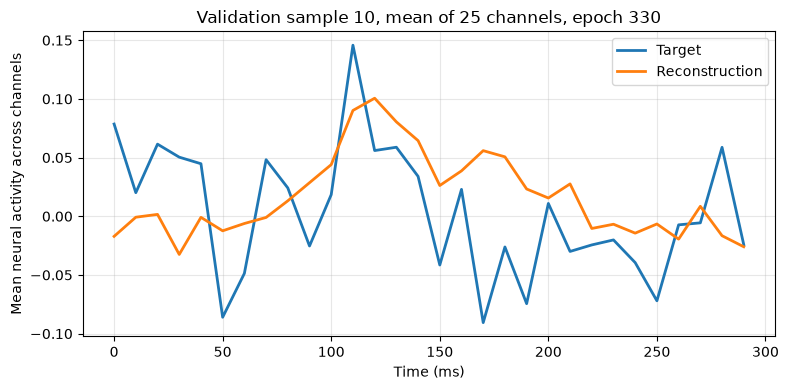

epoch 331/400 | train 0.042153 | validation 0.045900
epoch 332/400 | train 0.042162 | validation 0.045877
epoch 333/400 | train 0.042161 | validation 0.045826
epoch 334/400 | train 0.042149 | validation 0.045854
epoch 335/400 | train 0.042095 | validation 0.045830
epoch 336/400 | train 0.042150 | validation 0.045792
epoch 337/400 | train 0.042118 | validation 0.045763
epoch 338/400 | train 0.042133 | validation 0.045880
epoch 339/400 | train 0.042092 | validation 0.045851
epoch 340/400 | train 0.042107 | validation 0.046023


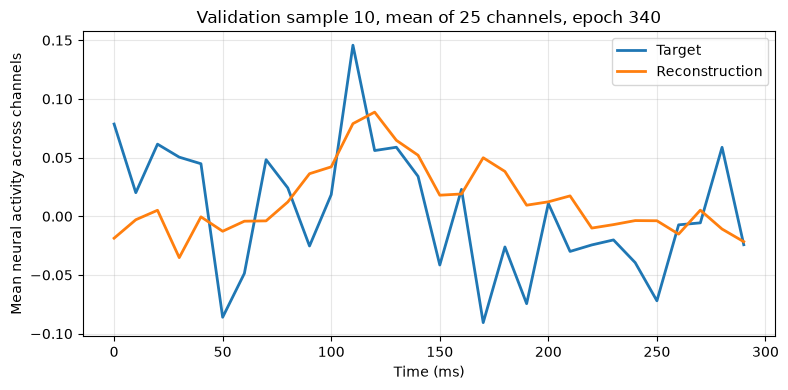

epoch 341/400 | train 0.042091 | validation 0.045875
epoch 342/400 | train 0.042127 | validation 0.045952
epoch 343/400 | train 0.042113 | validation 0.045759
epoch 344/400 | train 0.042113 | validation 0.045856
epoch 345/400 | train 0.042111 | validation 0.045878
epoch 346/400 | train 0.042074 | validation 0.045768
epoch 347/400 | train 0.042119 | validation 0.045630
epoch 348/400 | train 0.042124 | validation 0.045901
epoch 349/400 | train 0.042095 | validation 0.045824
epoch 350/400 | train 0.042090 | validation 0.045860


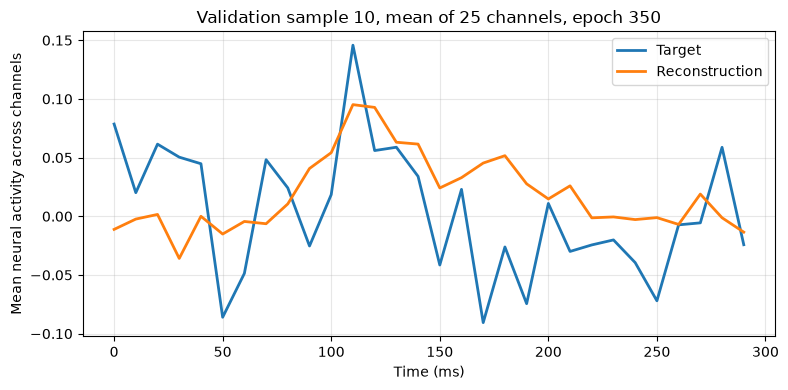

epoch 351/400 | train 0.042141 | validation 0.045808
epoch 352/400 | train 0.042096 | validation 0.045758
epoch 353/400 | train 0.042109 | validation 0.045805
epoch 354/400 | train 0.042078 | validation 0.045904
epoch 355/400 | train 0.042019 | validation 0.045920
epoch 356/400 | train 0.042060 | validation 0.045925
epoch 357/400 | train 0.042040 | validation 0.045862
epoch 358/400 | train 0.042065 | validation 0.045839
epoch 359/400 | train 0.042039 | validation 0.045842
epoch 360/400 | train 0.042044 | validation 0.045839


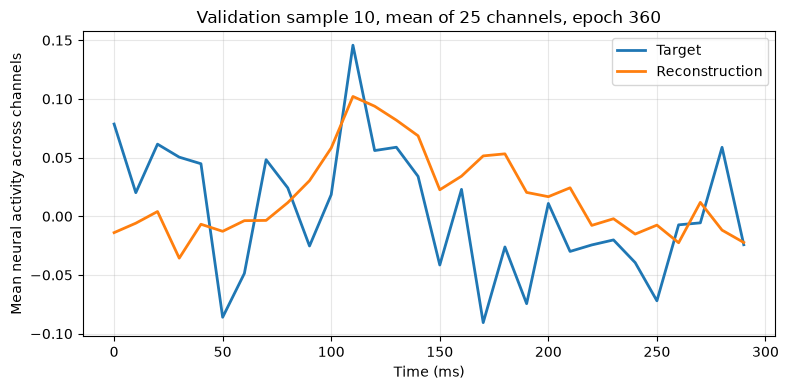

epoch 361/400 | train 0.042055 | validation 0.045827
epoch 362/400 | train 0.042042 | validation 0.045776
epoch 363/400 | train 0.042011 | validation 0.045865
epoch 364/400 | train 0.042034 | validation 0.045943
epoch 365/400 | train 0.042071 | validation 0.045732
epoch 366/400 | train 0.042052 | validation 0.045738
epoch 367/400 | train 0.042037 | validation 0.045846
epoch 368/400 | train 0.041981 | validation 0.045954
epoch 369/400 | train 0.042015 | validation 0.045912
epoch 370/400 | train 0.042035 | validation 0.045994


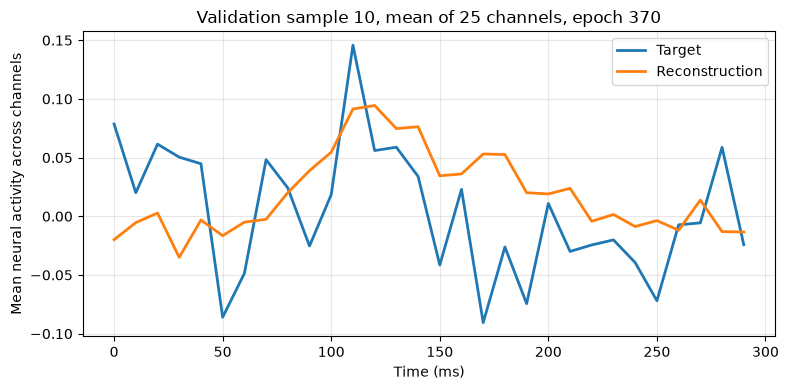

epoch 371/400 | train 0.042016 | validation 0.045953
epoch 372/400 | train 0.042071 | validation 0.045749
epoch 373/400 | train 0.042333 | validation 0.045690
epoch 374/400 | train 0.042357 | validation 0.045701
epoch 375/400 | train 0.042238 | validation 0.045790
epoch 376/400 | train 0.042162 | validation 0.045926
epoch 377/400 | train 0.042105 | validation 0.045904
epoch 378/400 | train 0.042074 | validation 0.045807
epoch 379/400 | train 0.042051 | validation 0.045812
epoch 380/400 | train 0.041996 | validation 0.046071


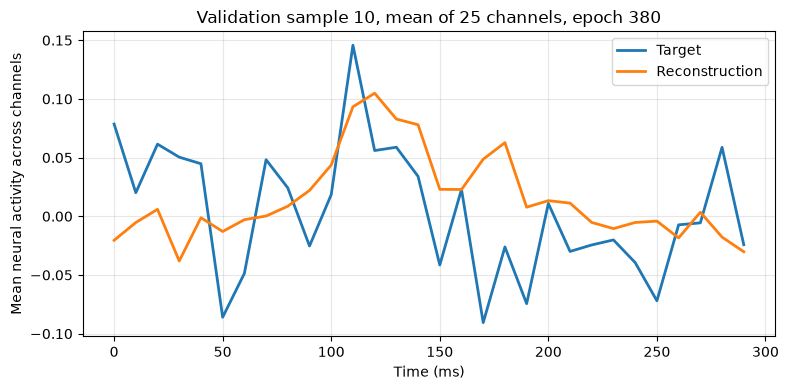

epoch 381/400 | train 0.042079 | validation 0.046040
epoch 382/400 | train 0.042037 | validation 0.046050
epoch 383/400 | train 0.042063 | validation 0.045810
epoch 384/400 | train 0.042057 | validation 0.045965
epoch 385/400 | train 0.042023 | validation 0.045872
epoch 386/400 | train 0.041983 | validation 0.045874
epoch 387/400 | train 0.041986 | validation 0.045964
epoch 388/400 | train 0.041980 | validation 0.045909
epoch 389/400 | train 0.041967 | validation 0.045928
epoch 390/400 | train 0.041998 | validation 0.045809


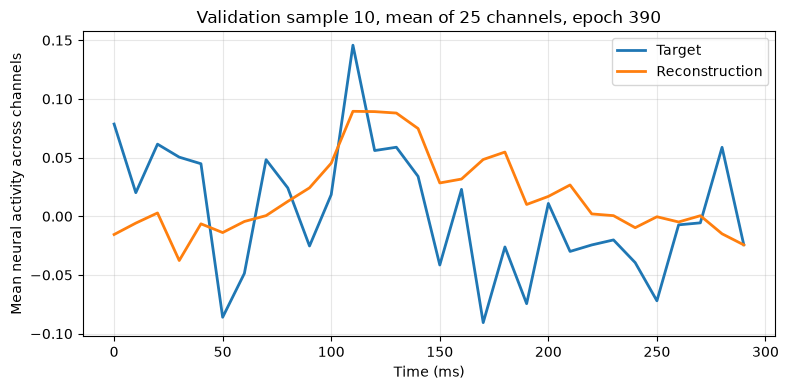

epoch 391/400 | train 0.041948 | validation 0.045875
epoch 392/400 | train 0.042126 | validation 0.045758
epoch 393/400 | train 0.042487 | validation 0.045511
epoch 394/400 | train 0.042374 | validation 0.045631
epoch 395/400 | train 0.042154 | validation 0.045791
epoch 396/400 | train 0.042016 | validation 0.045965
epoch 397/400 | train 0.042010 | validation 0.045842
epoch 398/400 | train 0.041969 | validation 0.045875
epoch 399/400 | train 0.041965 | validation 0.045909
epoch 400/400 | train 0.041939 | validation 0.045928


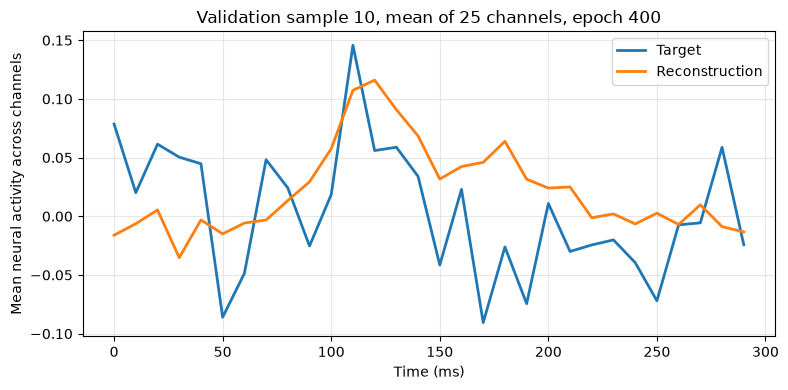

In [11]:
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError("validation_fraction must be between zero and one.")
# end if validation fraction is invalid

# Split unique images first, then assign all their repeated trials together.
full_dataset = loader.dataset
unique_image_indices = np.unique(full_dataset.image_indices)
n_validation_images = max(
    1,
    round(len(unique_image_indices) * cfg.validation_fraction),
)
if n_validation_images >= len(unique_image_indices):
    raise ValueError("The validation split leaves no training images.")
# end if training image split is empty

split_rng = np.random.default_rng(cfg.random_seed)
shuffled_image_indices = split_rng.permutation(unique_image_indices)
validation_image_indices = shuffled_image_indices[:n_validation_images]
is_validation_trial = np.isin(
    full_dataset.image_indices,
    validation_image_indices,
)
training_trial_indices = np.flatnonzero(~is_validation_trial).tolist()
validation_trial_indices = np.flatnonzero(is_validation_trial).tolist()
training_dataset = Subset(full_dataset, training_trial_indices)
validation_dataset = Subset(full_dataset, validation_trial_indices)

# Confirm that repeated presentations never cross the split boundary.
training_image_indices = set(
    full_dataset.image_indices[training_trial_indices].tolist()
)
validation_image_indices = set(
    full_dataset.image_indices[validation_trial_indices].tolist()
)
if training_image_indices & validation_image_indices:
    raise RuntimeError("An image appears in both training and validation.")
# end if repeated images leaked across splits
print(
    f"split: {len(training_image_indices)} images / "
    f"{len(training_trial_indices)} trials for training; "
    f"{len(validation_image_indices)} images / "
    f"{len(validation_trial_indices)} trials for validation"
)
pin_memory = torch.device(m.device).type == "cuda"
training_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=pin_memory,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# Configure regression optimization over trainable parameters only.
optimizer = torch.optim.AdamW(
    m.get_trainable_parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)
cost_function = neural_activity_timebin_mse_loss
use_precomputed_features = full_dataset.input_mode == "activations"
optimizer.zero_grad(set_to_none=True)

# Fit plain ridge on the same image-grouped split used by the neural model.
ridge_training_features, ridge_training_targets = (
    collect_concatenated_layer_regression_data(
        m,
        training_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_validation_features, ridge_validation_targets = (
    collect_concatenated_layer_regression_data(
        m,
        validation_loader,
        use_precomputed_features,
        device=m.device,
    )
)
ridge_encoding = linear_encoding(
    regression_type="ridge",
    cv_type="same",
)
ridge_encoding.fit(
    ridge_training_features,
    ridge_training_targets,
    transpose=False,
)
ridge_validation_predictions = ridge_encoding.predict(
    ridge_validation_features,
    transpose=False,
    transpose_output=False,
)
ridge_validation_mse = float(
    np.mean(
        (ridge_validation_predictions - ridge_validation_targets) ** 2
    )
)
print(
    f"concatenated-layer ridge | validation {ridge_validation_mse:.6f}"
)

# Evaluate the randomly initialized trainable model before any update.
initial_validation_loss = test_step(
    m,
    validation_loader,
    cost_function,
    use_precomputed_features,
    device=m.device,
)
print(f"epoch 000/{cfg.epochs:03d} | validation {initial_validation_loss:.6f}")
if cfg.reconstruction_plot_interval <= 0:
    raise ValueError("reconstruction_plot_interval must be positive.")
# end if reconstruction plot interval is invalid
plot_mean_channel_reconstruction(
    m,
    validation_dataset,
    cfg.reconstruction_sample_index,
    epoch=0,
    use_precomputed_features=use_precomputed_features,
    time_start_ms=cfg.time_start_ms,
    sampling_frequency=cfg.new_fs,
    device=m.device,
)

# Run one validation pass after every complete training epoch.
training_losses = []
validation_losses = []
for epoch in range(1, cfg.epochs + 1):
    training_loss = training_step(
        m,
        training_loader,
        optimizer,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    validation_loss = test_step(
        m,
        validation_loader,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)
    print(
        f"epoch {epoch:03d}/{cfg.epochs:03d} | "
        f"train {training_loss:.6f} | validation {validation_loss:.6f}"
    )

    # Show progress periodically and always include the final model.
    should_plot_reconstruction = (
        epoch % cfg.reconstruction_plot_interval == 0
        or epoch == cfg.epochs
    )
    if should_plot_reconstruction:
        plot_mean_channel_reconstruction(
            m,
            validation_dataset,
            cfg.reconstruction_sample_index,
            epoch=epoch,
            use_precomputed_features=use_precomputed_features,
            time_start_ms=cfg.time_start_ms,
            sampling_frequency=cfg.new_fs,
            device=m.device,
        )
    # end if reconstruction should be plotted
# end for epoch


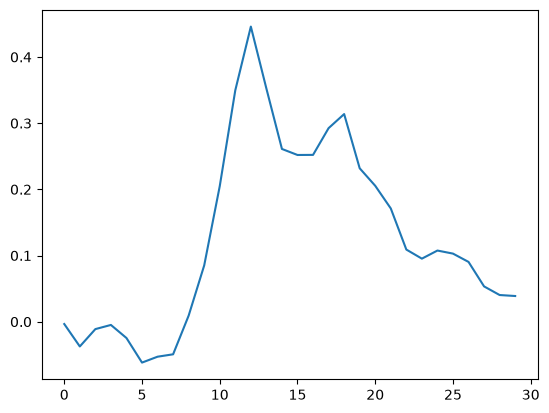

In [12]:
for i in training_loader:
    y = i[1][:, :, 1].mean(dim=0)
    plt.plot(y.detach().cpu().numpy())
    break

## Training curves, ridge reference, and temporal layer attention

The black star is the validation MSE of fixed-alpha ridge regression using the selected DINO layer vectors concatenated into one feature vector. Its final-epoch x-position is only for display; ridge is fitted once on the same image-grouped training split.

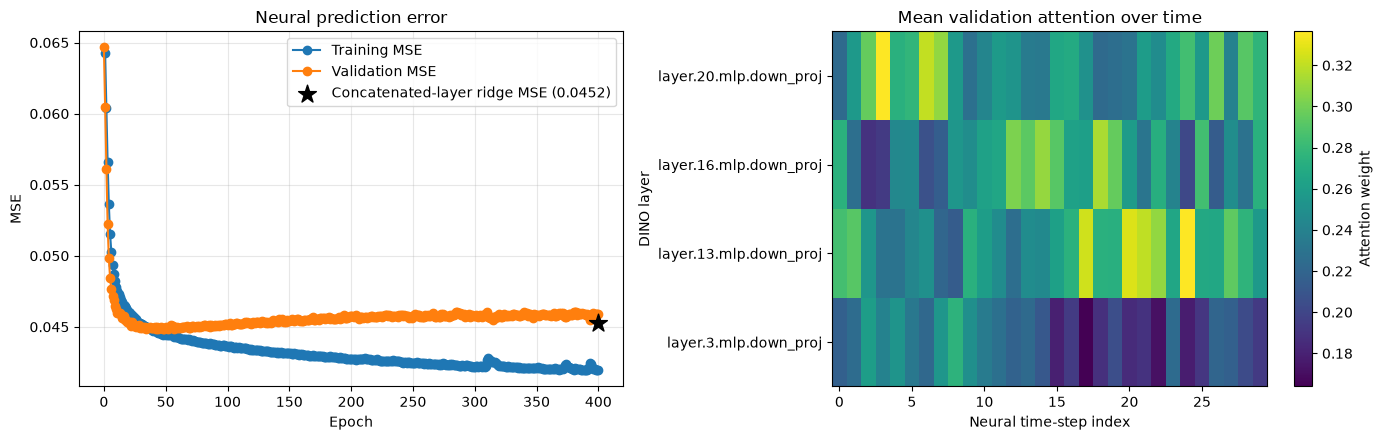

In [13]:
# Average attention over all validation stimuli after training.
m.eval()
validation_attention = []
with torch.no_grad():
    for inputs, _ in validation_loader:
        inputs = inputs.to(m.device)
        _, attention_weights = m(
            inputs,
            use_precomputed_features=use_precomputed_features,
        )
        validation_attention.append(attention_weights.cpu())
    # end for validation batch
# end with no gradient tracking

mean_coarse_attention = torch.cat(validation_attention, dim=0).mean(dim=0)

# Attention is constant inside each fine-time block produced by one coarse query.
mean_fine_attention = mean_coarse_attention.repeat_interleave(
    m.get_temporal_compression_ratio(),
    dim=0,
)

# Plot optimization error and the final validation-set attention schedule.
training_epochs = np.arange(1, len(training_losses) + 1)
validation_epochs = np.arange(0, len(validation_losses) + 1)
all_validation_losses = np.asarray(
    [initial_validation_loss, *validation_losses]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(
    training_epochs,
    training_losses,
    marker="o",
    label="Training MSE",
)
axes[0].plot(
    validation_epochs,
    all_validation_losses,
    marker="o",
    label="Validation MSE",
)
axes[0].scatter(
    validation_epochs[-1],
    ridge_validation_mse,
    marker="*",
    s=180,
    color="black",
    zorder=4,
    label=f"Concatenated-layer ridge MSE ({ridge_validation_mse:.4f})",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Neural prediction error")
axes[0].grid(alpha=0.3)
axes[0].legend()

attention_image = axes[1].imshow(
    mean_fine_attention.T.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
)
axes[1].set_xlabel("Neural time-step index")
axes[1].set_ylabel("DINO layer")
axes[1].set_title("Mean validation attention over time")
axes[1].set_yticks(np.arange(len(m.get_layer_names())))
axes[1].set_yticklabels(m.get_layer_names())
fig.colorbar(attention_image, ax=axes[1], label="Attention weight")
fig.tight_layout()
plt.show()
